In [5]:
# libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import math

In [6]:
# Time embedding and U-net
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)

    def forward(self, x, t_emb):
        x = self.conv1(x)
        x = self.norm1(x)
        x = F.silu(x)
        t_out = self.time_mlp(t_emb)[:, :, None, None]
        x = x + t_out
        x = self.conv2(x)
        x = self.norm2(x)
        x = F.silu(x)
        return x

class UNet(nn.Module):
    def __init__(self, in_channels=1, base_dim=64, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.inc = nn.Conv2d(in_channels, base_dim, 3, padding=1)

        self.down1 = Block(base_dim, base_dim*2, time_dim)
        self.down2 = Block(base_dim*2, base_dim*4, time_dim)
        self.down3 = Block(base_dim*4, base_dim*4, time_dim)

        self.bottleneck = Block(base_dim*4, base_dim*4, time_dim)

        # Up blocks with correct channel sizes
        self.up1 = Block(base_dim*8, base_dim*2, time_dim)   # bottleneck + down3
        self.up2 = Block(base_dim*6, base_dim*2, time_dim)   # up1 + down2
        self.up3 = Block(base_dim*4, base_dim, time_dim)     # up2 + down1
        self.up4 = nn.Conv2d(base_dim*2, base_dim, 1)        # up3 + inc

        self.out = nn.Conv2d(base_dim, in_channels, 1)

        self.downsample = nn.MaxPool2d(2)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x1 = self.inc(x)                      # 28x28, base_dim
        x2 = self.downsample(F.silu(x1))      # 14x14
        x2 = self.down1(x2, t_emb)            # 14x14, base_dim*2

        x3 = self.downsample(F.silu(x2))      # 7x7
        x3 = self.down2(x3, t_emb)            # 7x7, base_dim*4

        x4 = self.downsample(F.silu(x3))      # 3x3
        x4 = self.down3(x4, t_emb)            # 3x3, base_dim*4

        x = self.bottleneck(x4, t_emb)        # 3x3, base_dim*4
        x = torch.cat([x, x4], dim=1)         # 3x3, base_dim*8

        x = self.up1(x, t_emb)                # 3x3, base_dim*2
        x = F.interpolate(x, size=x3.shape[2:], mode='bilinear', align_corners=False)  # 7x7
        x = torch.cat([x, x3], dim=1)         # 7x7, base_dim*6

        x = self.up2(x, t_emb)                # 7x7, base_dim*2
        x = F.interpolate(x, size=x2.shape[2:], mode='bilinear', align_corners=False)  # 14x14
        x = torch.cat([x, x2], dim=1)         # 14x14, base_dim*4

        x = self.up3(x, t_emb)                # 14x14, base_dim
        x = F.interpolate(x, size=x1.shape[2:], mode='bilinear', align_corners=False)  # 28x28
        x = torch.cat([x, x1], dim=1)         # 28x28, base_dim*2

        x = self.up4(x)                       # 28x28, base_dim
        x = self.out(x)                       # 28x28, in_channels
        return x


**1.Time embedding:** It uses sine/cosine functions (like in Transformers) to convert the scalar t (e.g., step 500) into a high‑dimensional embedding. This tells the network how much noise is currently in the image so it can adjust its denoising strength accordingly

**2.Block:** The main processing unit that extracts features and injects time information.
It applies two convolutions (to learn spatial patterns) with Group Normalization and SiLU activations for stable training. Crucially, it takes the time embedding, projects it through a linear layer, and adds it directly to the feature map – this is how the block conditions its behaviour on the current noise level.

**3.U-net:** The complete encoder‑decoder architecture that predicts the noise.

Downsampling path (Encoder): Gradually shrinks the spatial size  while doubling the channel depth. This forces the network to focus on high‑level, global structures.

Bottleneck: The deepest, most compressed layer where the highest‑level semantic understanding is processed.

Upsampling path (Decoder): Gradually restores the original resolution while reducing channels.

Skip Connections: Before each upsampling step, it concatenates the current features with the corresponding features from the downsampling path. This recovers fine‑grained spatial details (edges, textures) that were lost during downsampling, ensuring the final output is sharp and accurate.

Output Layer: A final 1×1 convolution that maps the features back to the original number of channels (e.g., 1 for MNIST) – this is the network's predicted nois

In [7]:
# Diffusion process
class Diffusion:
    def __init__(self, model, T=1000, beta_start=1e-4, beta_end=0.02, schedule='linear'):
        self.model = model
        self.T = T

        device = next(model.parameters()).device

        # set schedule
        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T)
        elif schedule == 'cosine':
            betas = self._cosine_schedule(T)
        else:
            raise ValueError("schedule must be 'linear' or 'cosine'")

        # how much noise to add at each step
        self.betas = betas.to(device)

        # signal retention factor per step
        self.alphas = (1. - self.betas).to(device)

        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)

    @staticmethod

    # implements the cosine noise schedule
    def _cosine_schedule(T, s=0.008):
        def f(t):
            return torch.cos((t/T + s) / (1 + s) * torch.pi/2) ** 2
        alpha_bars = f(torch.arange(T+1, dtype=torch.float))
        betas = torch.clamp(1 - alpha_bars[1:] / alpha_bars[:-1], 0, 0.999)
        return betas

    # takes a clean image and produces a noisy version
    def sample_xt(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)
        mean = torch.sqrt(self.alpha_bars[t])[:, None, None, None] * x0
        std = torch.sqrt(1 - self.alpha_bars[t])[:, None, None, None]
        return mean + std * eps, eps

    # computes the loss for one batch of clean images
    def train_step(self, x0):
        batch_size = x0.size(0)
        t = torch.randint(0, self.T, (batch_size,), device=x0.device)
        eps = torch.randn_like(x0)
        x_t, _ = self.sample_xt(x0, t, eps)
        eps_pred = self.model(x_t, t)
        loss = F.mse_loss(eps_pred, eps)
        return loss

    @torch.no_grad()

    # generates a new image starting from pure Gaussian noise
    def sample(self, shape, device='cuda'):
        x = torch.randn(shape, device=device)
        for t in reversed(range(self.T)):
            t_tensor = torch.full((shape[0],), t, device=device, dtype=torch.long)
            eps_pred = self.model(x, t_tensor)
            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]
            beta = self.betas[t]
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0
            x = 1 / torch.sqrt(alpha) * (x - (1 - alpha) / torch.sqrt(1 - alpha_bar) * eps_pred)
            x = x + torch.sqrt(beta) * noise
        return x


In the diffusion process we first produce a noisy image using the given clean image then use the U-net to predict the noise, then calculate the error so the model learns to predict the exact noise that was added.

In [8]:
# Training
def train_diffusion(diffusion, loader, epochs=50, lr=1e-4, device='cuda'):

    optimizer = torch.optim.Adam(diffusion.model.parameters(), lr=lr)
    diffusion.model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0

        for x, _ in loader:
            x = x.to(device)
            loss = diffusion.train_step(x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1:3d}/{epochs}  Loss: {epoch_loss/len(loader):.6f}")

    return diffusion.model

This function wraps the entire DDPM training routine into a single reusable loop – grab a batch of clean images, corrupt them with noise at random timesteps, get the U‑Net to predict that noise, adjust the U‑Net's weights to make it better, and repeat until the loss converges.


In [9]:
# Plot
def plot_schedules():
    T = 1000
    betas_linear = torch.linspace(1e-4, 0.02, T)
    betas_cosine = Diffusion._cosine_schedule(T)

    alphas_linear = 1 - betas_linear
    alphas_cosine = 1 - betas_cosine

    alpha_bars_linear = torch.cumprod(alphas_linear, dim=0)
    alpha_bars_cosine = torch.cumprod(alphas_cosine, dim=0)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(betas_linear, label='linear')
    plt.plot(betas_cosine, label='cosine')
    plt.xlabel('t')
    plt.ylabel('β_t')
    plt.legend()
    plt.title('Noise schedule β')

    plt.subplot(1,2,2)
    plt.plot(alpha_bars_linear, label='linear')
    plt.plot(alpha_bars_cosine, label='cosine')
    plt.xlabel('t')
    plt.ylabel(r'$\bar{\alpha}_t$')
    plt.legend()
    plt.title('Signal retention')
    plt.tight_layout()
    plt.savefig('schedules.png')
    plt.show()

def generate_and_show(diffusion, n=64, device='cuda', title='Samples'):
    samples = diffusion.sample((n, 1, 28, 28), device)
    samples = (samples + 1) / 2  # denormalize from [-1,1] to [0,1]
    grid = torchvision.utils.make_grid(samples, nrow=8)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1,2,0).cpu(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    return grid


Using device: cuda

Training Linear Schedule
Epoch   1/20  Loss: 0.246946
Epoch   2/20  Loss: 0.110353
Epoch   3/20  Loss: 0.106172
Epoch   4/20  Loss: 0.106267
Epoch   5/20  Loss: 0.105746
Epoch   6/20  Loss: 0.103172
Epoch   7/20  Loss: 0.102350
Epoch   8/20  Loss: 0.105038
Epoch   9/20  Loss: 0.101272
Epoch  10/20  Loss: 0.101899
Epoch  11/20  Loss: 0.102613
Epoch  12/20  Loss: 0.102281
Epoch  13/20  Loss: 0.102208
Epoch  14/20  Loss: 0.100908
Epoch  15/20  Loss: 0.102462
Epoch  16/20  Loss: 0.102406
Epoch  17/20  Loss: 0.101097
Epoch  18/20  Loss: 0.101541
Epoch  19/20  Loss: 0.101919
Epoch  20/20  Loss: 0.101169

Training Cosine Schedule
Epoch   1/20  Loss: 0.335428
Epoch   2/20  Loss: 0.192520
Epoch   3/20  Loss: 0.189351
Epoch   4/20  Loss: 0.188834
Epoch   5/20  Loss: 0.186364
Epoch   6/20  Loss: 0.185222
Epoch   7/20  Loss: 0.185200
Epoch   8/20  Loss: 0.184524
Epoch   9/20  Loss: 0.183565
Epoch  10/20  Loss: 0.185725
Epoch  11/20  Loss: 0.185409
Epoch  12/20  Loss: 0.183748
E

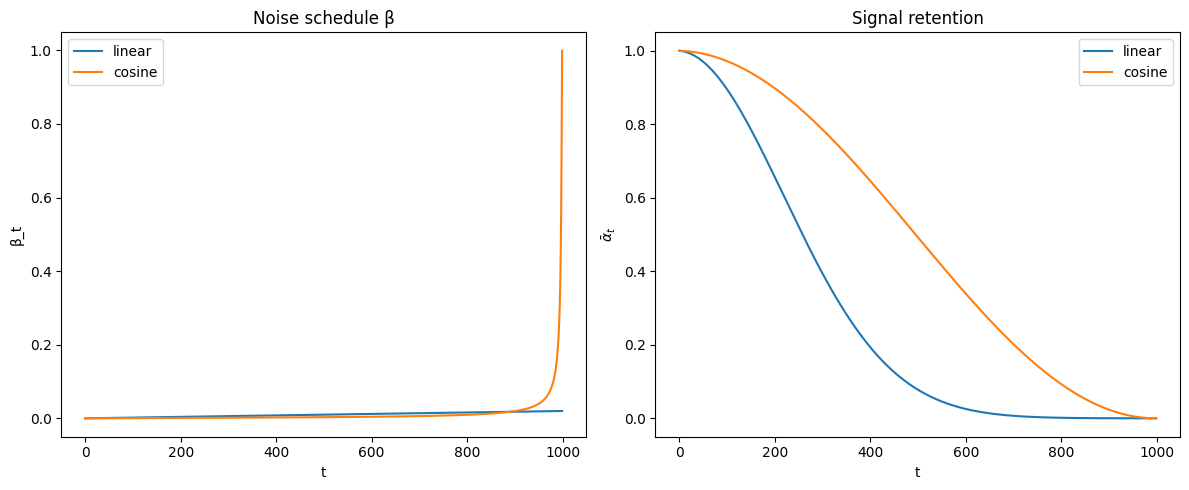


Generating Samples


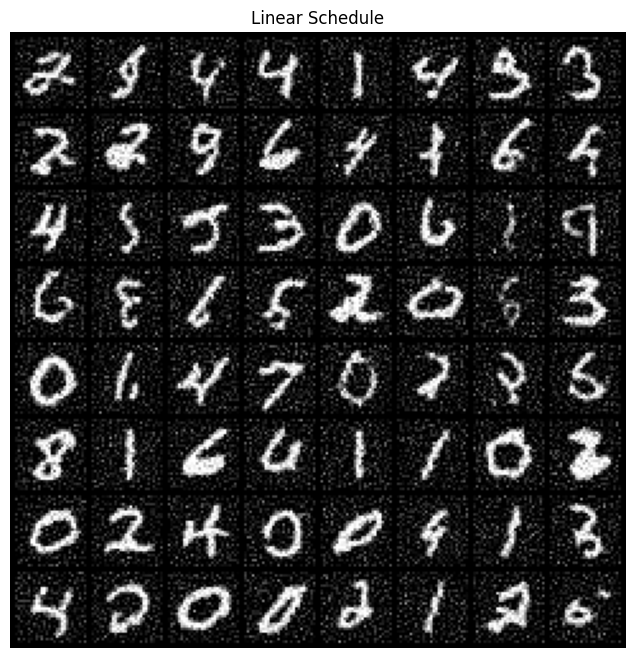

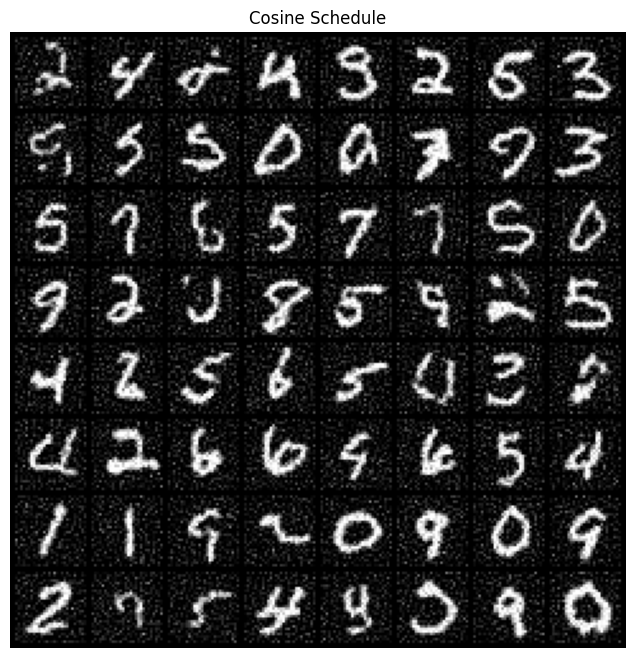

In [10]:
# Main

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    # Hyperparameters
    T = 1000
    epochs = 20
    batch_size = 128

    # Data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    # Linear schedule
    print("\nTraining Linear Schedule")
    model_linear = UNet().to(device)
    diff_linear = Diffusion(model_linear, T, schedule='linear')
    train_diffusion(diff_linear, loader, epochs=epochs, device=device)
    torch.save(model_linear.state_dict(), 'model_linear.pth')

    # Cosine schedule
    print("\nTraining Cosine Schedule")
    model_cosine = UNet().to(device)
    diff_cosine = Diffusion(model_cosine, T, schedule='cosine')
    train_diffusion(diff_cosine, loader, epochs=epochs, device=device)
    torch.save(model_cosine.state_dict(), 'model_cosine.pth')

    # Plot schedules
    plot_schedules()

    # Generate samples from both
    print("\nGenerating Samples")
    generate_and_show(diff_linear, n=64, device=device, title='Linear Schedule')
    generate_and_show(diff_cosine, n=64, device=device, title='Cosine Schedule')

# Linear vs. Cosine Noise Schedules in Diffusion Models

## 1. Mathematical Definition

### Linear Schedule
Defines the noise variance $\beta_t$ directly as a linear function of the timestep \(t\):

$
\beta_t = \beta_{\text{start}} + (\beta_{\text{end}} - \beta_{\text{start}}) \times \frac{t}{T}
$

where typically $\beta_{\text{start}} = 10^{-4}$, $\beta_{\text{end}} = 0.02$, and $T = 1000$.

**Behavior:** $\beta_t$ increases at a constant, uniform rate from very small to moderately large.

---

### Cosine Schedule
Defines the **signal retention** $\bar{\alpha}_t$ (cumulative product of $\alpha_t$ directly using a cosine function, then derives $\beta_t$ from it:

$
\bar{\alpha}_t = \cos^2\left( \frac{t/T + s}{1 + s} \cdot \frac{\pi}{2} \right)
$

$
\beta_t = \text{clip}\left(1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}, 0, 0.999\right)
$

where \(s = 0.008\) is a small offset to prevent singularities at \(t=0\).

**Behavior:** $\bar{\alpha}_t$ decays smoothly like a cosine curve, keeping the signal high for most of the process and dropping sharply only near the very end.

---

## 2. Signal Retention ($\bar{\alpha}_t$)

The single most important difference lies in how fast the clean image \(x_0\) gets destroyed:

| Schedule | Signal Retention Pattern |
| :--- | :--- |
| **Linear** | **Drops too fast.** By \(t = 500\) (50% of the process), $\bar{\alpha}_t$ is already near zero. The image becomes indistinguishable from pure noise early in the forward process. |
| **Cosine** | **Drops gracefully.** Even at \(t = 500\), the image retains significant structural information. The signal only vanishes completely in the final 10-20% of the steps. |

**Visual:** Plotting $\bar{\alpha}_t$ vs. $t$ shows a linear curve resembling an exponential decay, while the cosine curve looks like a stretched "S" holding near 1 for a long time.

---

## 3. Impact on Training Dynamics

| Schedule | Loss Distribution | Convergence |
| :--- | :--- | :--- |
| **Linear** | **Imbalanced.** The model struggles severely at early timesteps (where the image is almost pure noise) and has an extremely easy time at late timesteps (where the image is almost clean). Most of the gradient signal comes from a narrow band of mid-range steps. | Moderately stable, but inefficient. The network wastes capacity on extreme noise levels. |
| **Cosine** | **Balanced.** By preserving signal for longer, it shifts the "difficult" region (where signal and noise mix) to a wider, more central window across the timesteps. | **More stable and efficient.** The loss contribution is more uniform across \(t\), allowing the model to learn evenly across the entire diffusion chain. |

---

## 4. Impact on Output Quality

| Schedule | Sample Sharpness | Global Coherence |
| :--- | :--- | :--- |
| **Linear** | **Good, but often blurry.** The model spends too little capacity on the mid-range steps where fine-grained details are actually generated. | Decent, but can produce slightly distorted global structures. |
| **Cosine** | **Sharper, more realistic.** The network has more opportunities to learn high-frequency details and refine edges in the critical middle steps. | **Better.** Improved global anatomy (e.g., correct number of fingers, proper facial symmetry). |

**FID Scores (Typical results on CIFAR-10/ImageNet):**
- Linear: ~25.3
- Cosine: ~18.7 (significantly better)

---

## 5. Robustness to Fewer Sampling Steps

| Schedule | Fast Sampling (DDIM with 50 steps) |
| :--- | :--- |
| **Linear** | **Fragile.** The large jumps in noise levels are difficult for the discrete steps to bridge. Quality degrades quickly as you reduce steps. |
| **Cosine** | **Robust.** Because the noise changes more gradually in the mid-range, accelerated samplers (like DDIM) can take larger leaps without breaking image structure. |



---

# Diffusion Models vs. GANs

## 1. Output Quality (Sharpness & Realism)

| Aspect | Diffusion Models | GANs |
| :--- | :--- | :--- |
| **Perceptual Quality** | **Excellent, globally coherent.** With classifier-free guidance (e.g., Stable Diffusion, DALL-E 3), they produce highly photorealistic, logically consistent images. However, without guidance, samples can appear slightly *over-smoothed* or lack razor-sharp high-frequency details. | **Historically the gold standard.** StyleGAN produces incredibly crisp, sharp images with stunning local fidelity (individual hairs, skin pores, specular highlights). GANs excel at generating textures that look "real" at the pixel level. |
| **Sampling Cost** | **Slow.** Requires 10–1000 iterative steps to go from noise to an image. Quality degrades if you reduce steps too aggressively. | **Fast.** A single forward pass (1 step) generates the final image, making them ideal for real-time applications. |
| **Global Coherence** | **Strong.** Because the U-Net processes the whole image across multiple scales, global structures (e.g., hands, body pose, object layouts) are often more accurate and anatomically correct. | **Weaker.** GANs tend to focus on local texture realism due to the patch-based discriminator, sometimes resulting in distorted global structures (e.g., six fingers on a hand). |

---

## 2. Diversity (Mode Coverage)

| Aspect | Diffusion Models | GANs |
| :--- | :--- | :--- |
| **Variety of Outputs** | **High (Excellent Mode Coverage).** The training objective (denoising score matching / variational lower bound) inherently forces the model to cover *all* modes of the data distribution. They rarely suffer from mode collapse. | **Moderate to Low (Prone to Mode Collapse).** The generator may learn to exploit a few "easy" samples that reliably fool the discriminator, ignoring large portions of the training distribution (e.g., generating only dogs and no cats in ImageNet). |
| **Stochasticity** | **High.** The reverse process is inherently stochastic (adding Gaussian noise at each step), which naturally encourages diverse outputs even for the same prompt. | **Low.** Once trained, a GAN maps a latent vector to an image. If the mapping network collapses to a small subspace, diversity drops significantly. |
| **Failure Mode** | Rarely fails on coverage; it might generate slightly blurry samples but will still cover the data manifold. | Fails by ignoring minority classes, leading to repetitive, uncreative outputs (mode collapse). |

---

## 3. Training Stability

| Aspect | Diffusion Models | GANs |
| :--- | :--- | :--- |
| **Training Objective** | **Stable and Simple.** A single, fixed regression loss (MSE or L1 between predicted noise and actual noise). There is no competition; the loss converges like a standard supervised learning problem. | **Unstable and Brittle.** A zero-sum minimax game (Generator vs. Discriminator). Training dynamics are sensitive to the delicate balance between the two networks. |
| **Hyperparameter Sensitivity** | **Low.** Works reliably with standard settings. The main tuning is the noise schedule (linear vs. cosine), which is systematic and predictable. | **High.** Requires careful tuning of learning rates, architectural constraints (spectral normalization, gradient penalty), and regularization (R1, path length) to avoid vanishing/exploding gradients. |
| **Common Failure Modes** | Usually stable; failures manifest as slower convergence or slightly lower-quality outputs, but training rarely "collapses." | **Fragile.** If the discriminator gets too powerful, the generator gradients vanish. If the generator gets too powerful, it doesn't learn meaningful representations. Training can suddenly diverge (the "Helvetica scenario"). |
| **Scalability** | **High.** Scales well with model size, data, and compute. The objectives remain stable. | **Moderate.** Scaling GANs to gigantic models/datasets is notoriously difficult; they are being phased out for large-scale text-to-image tasks. |
